In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import scipy
import yaml

import cv2
from skimage.measure import regionprops, label, shannon_entropy
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage import img_as_ubyte
from brisque import BRISQUE
from skvideo.measure import niqe
from pypiqe import piqe
from mahotas.features import zernike_moments
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

import torch
from torch.utils.data import Subset, Dataset, DataLoader
from torchvision import datasets, transforms
import segmentation_models_pytorch as smp

# Patch imresize if missing
if not hasattr(scipy.misc, "imresize"):
    def imresize(arr, size, interp=None, mode=None):
        if isinstance(size, float):  # scale factor
            new_shape = (int(arr.shape[0] * size), int(arr.shape[1] * size))
        else:
            new_shape = size[:2]
        arr_resized = resize(arr, new_shape, order=3, mode="reflect", anti_aliasing=True)
        arr_resized = (arr_resized * 255).astype(np.uint8)
        return arr_resized
    scipy.misc.imresize = imresize

# Patch for deprecated NumPy aliases (for backward compatibility)
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'bool'):
    np.bool = bool

In [2]:
DATA_DIR = r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'
MODEL_NAME = "deeplabv3plus" # Available options are: ['unet', 'unetplusplus', 'manet', 'linknet', 'fpn', 'pspnet', 'deeplabv3', 'deeplabv3plus', 'pan', 'upernet', 'segformer', 'dpt']"
ENCODER_NAME = "resnext50_32x4d"
MODEL_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/2_segmentation/CUB/deeplabv3plus/lightning_logs/version_2/checkpoints/epoch=199-step=13400.ckpt"
DEVICE_ID = 1
EPOCHS = 300
LEARNING_RATE = 1e-4
BATCH_SIZE = 128
IMAGE_SIZE = 320
SEED = 42

In [3]:
# Create SIFT and ORB detectors once
sift = cv2.SIFT_create()
orb = cv2.ORB_create()
bri_obj = BRISQUE(url=False)

def extract_base_features(mask):
    """Compute geometric, Zernike, Fourier, and texture shape descriptors from a binary mask."""
    
    features = ["area", "perimeter", "aspect_ratio", "extent", "solidity", "eccentricity", 
        "orientation", "circularity", "elongation", "compactness"]
    
    if mask is None or mask.sum() == 0:
        return {f: 0 for f in features}

    # --- Region properties ---
    # mask = mask.astype(np.uint8)
    labeled = label(mask)
    props = regionprops(labeled)
    if len(props) == 0:
        return {f: 0 for f in features}
    p = props[0]
    major_axis = p.major_axis_length
    minor_axis = p.minor_axis_length

    # ----- base shape features -----
    area = p.area
    perimeter = max(p.perimeter, 1e-6) # Ignoring too small perimeters
    aspect_ratio = major_axis / minor_axis if minor_axis > 0 else 0 # L_major / L_minor
    extent = p.extent
    solidity = p.solidity
    eccentricity = p.eccentricity
    orientation = p.orientation
    circularity = 4 * np.pi * area / (perimeter ** 2)
    elongation = 1 - (minor_axis / major_axis) if major_axis > 0 else 0
    # convexity = p.perimeter_convex / perimeter
    compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-6)

    # ----- Assemble features -----
    features_d = {
        "area": area,
        "perimeter": perimeter,
        "aspect_ratio": aspect_ratio,
        "extent": extent,
        "solidity": solidity,
        "eccentricity": eccentricity,
        "orientation": orientation,
        "circularity": circularity,
        "elongation": elongation,
        "compactness": compactness
    }
    return features_d

def compute_sift_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY) # converts image into uint8 and mask as input
    keypoints, descriptors = sift.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 128), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_orb_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY)
    keypoints, descriptors = orb.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 32), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_hu_moments(mask):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    moments = cv2.moments(mask)
    hu = cv2.HuMoments(moments).flatten()
    hu = np.log(np.abs(hu) + 1e-12) # log-scale for stability
    return hu

def compute_zernike_moments(mask, degree=8):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    radius = min(mask.shape) // 2
    mask_norm = mask / mask.max() if mask.max() > 0 else mask
    zern = zernike_moments(mask_norm, radius=radius, degree=degree)
    return zern

# *** Updated fourier descriptors (Dec 4, 2025)
def compute_fourier_descriptors(mask, image=None, fourier_harmonics=20, visualize=False):
    if not isinstance(mask, np.ndarray): # Ensure proper mask format
        mask = mask.numpy().astype(np.uint8)
    # --- 2. Find largest contour (object part) ---
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    cnt = max(contours, key=cv2.contourArea)
    if len(cnt) < 3:
        # Too few points for Fourier transform
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    
    # Translation invariance: center contour
    complex_contour = cnt[:,0,0] + 1j * cnt[:,0,1]
    fd = np.fft.fft(complex_contour)
    
    if visualize: # ** IMPORTANT: Visualization uses raw contour (so you can see the real shape), descriptors are centered.
        # Convert image if needed
        H, W = mask.shape
        if image is not None:
            if isinstance(image, torch.Tensor):
                image = image.detach().cpu().numpy().transpose(1, 2, 0)
            elif isinstance(image, Image.Image):
                image = np.array(image.convert('RGB'))
            elif image.dtype != np.uint8:  # NumPy float → uint8
                image = (image*255).astype(np.uint8)
            img_draw = image.copy()
        else:
            img_draw = np.zeros((H, W, 3), dtype=np.uint8)
        cv2.drawContours(img_draw, [cnt.astype(np.int32)], -1, (0, 255, 0), 2)

        fd_recon = fd.copy()
        keep = fourier_harmonics
        if 2 * keep < len(fd_recon):
            fd_recon[keep:-keep] = 0 # Safe zeroing
        else:
            fd_recon[keep:] = 0
        recon = np.fft.ifft(fd_recon)
        pts = np.column_stack((recon.real, recon.imag)).astype(np.int32)

        for i in range(len(pts)):
            cv2.line(img_draw, tuple(pts[i]), tuple(pts[(i + 1) % len(pts)]), (255, 0, 255), 1)
        plt.figure(figsize=(16, 6))
        plt.imshow(img_draw)
        plt.axis('off')
        plt.title("Shape Descriptors Overlay")
        plt.legend(
            handles=[
                Patch(facecolor='green', edgecolor='green'),
                Patch(facecolor='magenta', edgecolor='magenta')
            ],
            labels=["Contour", "Fourier Reconstruction"],
            loc='upper right'
        )
        plt.show()
    
    cnt_centered = complex_contour - np.mean(complex_contour)
    fd = np.fft.fft(cnt_centered)
    if len(fd) < 2 or np.abs(fd[1]) == 0:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)

    # Scale invariance: divide by first descriptor magnitude
    fd = fd / np.abs(fd[1])

    # Rotation invariance: use only magnitudes
    fd_normalized = np.abs(fd)

    # Keep only first N harmonics
    fd_truncated = fd_normalized[:fourier_harmonics]
    if len(fd_truncated) < fourier_harmonics:
        fd_truncated = np.concatenate([fd_truncated, np.full((fourier_harmonics - len(fd_truncated)), np.nan)])
    return fd_truncated

def extract_shape_features(image, mask):
    # Compute base features
    features = extract_base_features(mask)

    # Compute sift features
    sift_kp, sift_ds = compute_sift_features(image, mask)
    sift_sizes = [k.size for k in sift_kp]
    if sift_ds.shape[0] > 0:
        sift_mean_ds = np.nanmean(sift_ds, axis=0)
    else:
        sift_mean_ds = np.full(128, np.nan)
    sift_dict = {f'sift_ds{i+1}': sift_mean_ds[i] for i in range(len(sift_mean_ds))}
    sift_dict['sift_kp_n'] = len(sift_kp)
    sift_dict['sift_kp_size'] = np.max(sift_sizes) if sift_sizes else 0

    # Compute orb features
    orb_kp, orb_ds = compute_orb_features(image, mask)
    if orb_ds.shape[0] > 0:
        orb_mean_ds = np.nanmean(orb_ds, axis=0)
    else:
        orb_mean_ds = np.full(32, np.nan)
    orb_dict = {f'orb_ds{i+1}': orb_mean_ds[i] for i in range(len(orb_mean_ds))}
    orb_dict['orb_kp_n'] = len(orb_kp)

    # Compute hu moments
    hu_moments = compute_hu_moments(mask)
    hu_dict = {f"hu{i+1}": hu_moments[i] for i in range(len(hu_moments))}

    # Compute Zernike moments
    zern_moments = compute_zernike_moments(mask, degree=8)
    zern_dict = {f"zernike_{i+1}": zern_moments[i] for i in range(len(zern_moments))}

    # Compute fourier descriptors
    fourier_ds = compute_fourier_descriptors(mask, fourier_harmonics=20)
    fourier_dict = {f"fourier_{i+1}": fourier_ds[i] for i in range(len(fourier_ds))}

    features.update(sift_dict)
    features.update(orb_dict)
    features.update(hu_dict)
    features.update(zern_dict)
    features.update(fourier_dict)
    converted = {k: np.float32(v) for k, v in features.items()}
    return converted

def extract_visual_features(image, mask):
    # --- 1. Ensure binary uint8 mask ---
    if not isinstance(mask, np.ndarray):
        mask = mask.numpy().astype(np.uint8)
    # Convert image to numpy
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    elif isinstance(image, Image.Image):
        image = np.array(image.convert('RGB'))
    img_cropped = np.zeros_like(image)
    img_cropped[mask==1] = image[mask==1]
    # plt.imshow(img_cropped)

    # --- Brightness ---
    brightness = np.mean(img_cropped)

    # --- Contrast (standard deviation of luminance) ---
    gray = rgb2gray(img_cropped)
    contrast = np.std(gray)

    # --- Sharpness (variance of Laplacian) ---
    gray_8u = (gray * 255).astype(np.uint8)
    lap_var = cv2.Laplacian(gray_8u, cv2.CV_64F).var()

    # --- Colorfulness (Hasler & Süsstrunk, 2003) ---
    (R, G, B) = cv2.split(img_cropped)
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_rg, std_yb = np.std(rg), np.std(yb)
    mean_rg, mean_yb = np.mean(rg), np.mean(yb)
    colorfulness = np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2)

    # --- Entropy (texture complexity) ---
    entropy = shannon_entropy(gray)

    # BRISQUE
    # bri_obj = BRISQUE(url=False)
    brisque_score = bri_obj.score(img_cropped)

    # NIQE
    niqe_score = niqe(gray)

    # PIQE
    piqe_score, activityMask, noticeableArtifactMask, noiseMask = piqe(gray)

    # --- Aggregate descriptors ---
    descriptors = {
        "brightness": np.float32(brightness),
        "contrast": np.float32(contrast),
        "sharpness": np.float32(lap_var),
        "colorfulness": np.float32(colorfulness),
        "entropy": np.float32(entropy),
        "brisque": np.float32(brisque_score),
        "niqe": np.float32(niqe_score.item()),
        "piqe": np.float32(piqe_score)
    }
    return descriptors

def extract_combined_features(image, mask): 
    # ---- Convert once ----
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    if isinstance(image, Image.Image):
        image = np.asarray(image)
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy().astype(np.uint8)
    mask_u8 = mask.astype(np.uint8)
    image_f = (image - image.min()) / (image.max() - image.min() + 1e-8) # Linearly rescale to [0, 1] and avoid division by zero
    image_u8 = img_as_ubyte(image_f)

    combined_features = extract_shape_features(image_u8, mask_u8)
    vis_features = extract_visual_features(image_f, mask_u8)
    combined_features.update(vis_features)
    return combined_features

In [4]:
def read_part_labels(path):
    with open(path) as f:
        labels = [l.strip() for l in f if l.strip()]
        return labels

# Load segmentation model
def load_segmentation(name, encoder_name, checkpoint_path):    
    # Define the segmentation model and load weights
    model = smp.create_model(
                name,
                encoder_name=encoder_name,
                in_channels = 3, # 3 for RGB images
                classes = 12
            ).to(f"cuda:{DEVICE_ID}")
    # checkpoint_path = r"/home/c/choton/beemachine/codes/everyday_test/oct1_25/segmentation_models/lightning_logs/fpn/lightning_logs/version_0/checkpoints/epoch=199-step=37400.ckpt"
    checkpoint = torch.load(checkpoint_path, map_location=rf"cuda:{DEVICE_ID}")

    # Sometimes Lightning adds "state_dict"
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

        # Remove "model." or "net." prefixes if present
        new_state_dict = {k.replace("model.", "").replace("net.", ""): v 
                        for k, v in state_dict.items() if k not in ["mean", "std"]}

        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(checkpoint)
    # model.to(f"cuda:{DEVICE_ID}")
    return model

#  Segmentation prediction
def predict_mask(model, image_tensor):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(f"cuda:{DEVICE_ID}")
        output = model(image_tensor.unsqueeze(0))
        if isinstance(output, dict):  # handle SMP model dict outputs
            output = output['out']
        probs = torch.softmax(output, dim=1)
        mask = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy()
    return mask  # (H, W) integer mask

def visualize(**images):
    """Plot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(" ".join(name.split("_")).title())

        # If it's an image, plot it as RGB
        if name == "image":
            # # Convert CHW to HWC for plotting
            # image = image.transpose(1, 2, 0)
            np_image = np.array(image)
            np_image = np_image.transpose(1, 2, 0)
            plt.imshow(np_image)
        else:
            plt.imshow(image, cmap="tab20")
    plt.show()

In [5]:
def extract_all_features(image, mask):
    """
    Generalized feature extraction for N body parts.
    mask: 2D array where each unique integer >0 is a body part ID.
    """

    # Get unique body-part IDs (excluding background 0)
    part_ids = sorted([pid for pid in np.unique(mask) if pid > 0])

    # Extract features for each part
    part_features = {}
    for pid in part_ids:
        part_mask = mask == pid
        feats = extract_combined_features(image, part_mask)
        part_features[pid] = feats

    # Full body features
    full_mask = mask > 0
    full_feats = extract_combined_features(image, full_mask)

    # Compute area sums
    areas = {pid: part_features[pid]["area"] for pid in part_ids}
    total_area = sum(areas.values()) + 1e-6

    # ----------- Ratio Features -----------
    # Pairwise ratios: area_i / area_j
    ratio_feats = {}
    for i in part_ids:
        for j in part_ids:
            if i != j:
                ratio_feats[f"area_ratio_part{i}_to_part{j}"] = areas[i] / (areas[j] + 1e-6)

    # Area-to-total ratios
    for pid in part_ids:
        ratio_feats[f"area_ratio_part{pid}_to_total"] = areas[pid] / total_area

    # ----------- Build Record -----------
    record = {}

    # Add each part's features
    for pid in part_ids:
        feats = part_features[pid]
        for k, v in feats.items():
            record[f"part{pid}_{k}"] = v

    # Add full-body features
    for k, v in full_feats.items():
        record[f"full_{k}"] = v

    # Add ratio features
    record.update(ratio_feats)
    return record

In [6]:
segmentation_model = load_segmentation(
            name=MODEL_NAME, 
            encoder_name=ENCODER_NAME, 
            checkpoint_path=MODEL_WEIGHTS
        )
transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.5016, 0.4647, 0.3782], std=[0.2738, 0.2654, 0.2885]) # Computed using the find_mean_and_sd_of_partwhole_dataset script
        ])

In [7]:
class PartWholeDataset(Dataset):
    def __init__(self, root, images_dir="images", image_size=320):
        self.images_dir = os.path.join(root, images_dir)
        self.image_size = image_size

        # -------- Labels --------
        self.labels = ["background"] + read_part_labels(
            os.path.join(root, "part_labels.txt")
        )
        self.num_parts = len(self.labels)

        # class folders
        self.classes = sorted(os.listdir(self.images_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        # collect image paths WITH class
        self.samples = []
        for c in self.classes:
            cls_img_dir = os.path.join(self.images_dir, c)
            for fname in os.listdir(cls_img_dir):
                if fname.lower().endswith((".jpg", ".png", ".jpeg")):
                    img_path = os.path.join(cls_img_dir, fname)
                    self.samples.append((img_path, self.class_to_idx[c]))
        self.samples = sorted(self.samples)

        # image transform
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size),
                              interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, class_id = self.samples[idx]

        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        return img, class_id

In [8]:
# Create Dataset
full_dataset = PartWholeDataset(root=DATA_DIR, images_dir="images", image_size=IMAGE_SIZE)
torch.manual_seed(SEED)

original image size: <built-in method size of Tensor object at 0x7f05ee786cf0> mask shape: (320, 320) class_ids: [ 0  1  2  4  5  6  7 11]
feature length: 1913
{'part1_area': np.float32(1733.0), 'part1_perimeter': np.float32(280.2498), 'part1_aspect_ratio': np.float32(2.4518328), 'part1_extent': np.float32(0.39620486), 'part1_solidity': np.float32(0.6361968), 'part1_eccentricity': np.float32(0.9130453), 'part1_orientation': np.float32(-0.9817563), 'part1_circularity': np.float32(0.27727956), 'part1_elongation': np.float32(0.59214187), 'part1_compactness': np.float32(3.6064684), 'part1_sift_ds1': np.float32(29.666666), 'part1_sift_ds2': np.float32(26.11111), 'part1_sift_ds3': np.float32(8.111111), 'part1_sift_ds4': np.float32(46.22222), 'part1_sift_ds5': np.float32(27.777779), 'part1_sift_ds6': np.float32(13.333333), 'part1_sift_ds7': np.float32(7.4444447), 'part1_sift_ds8': np.float32(3.6666667), 'part1_sift_ds9': np.float32(92.111115), 'part1_sift_ds10': np.float32(33.555557), 'part1_

/tmp/ipykernel_499142/1869922507.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


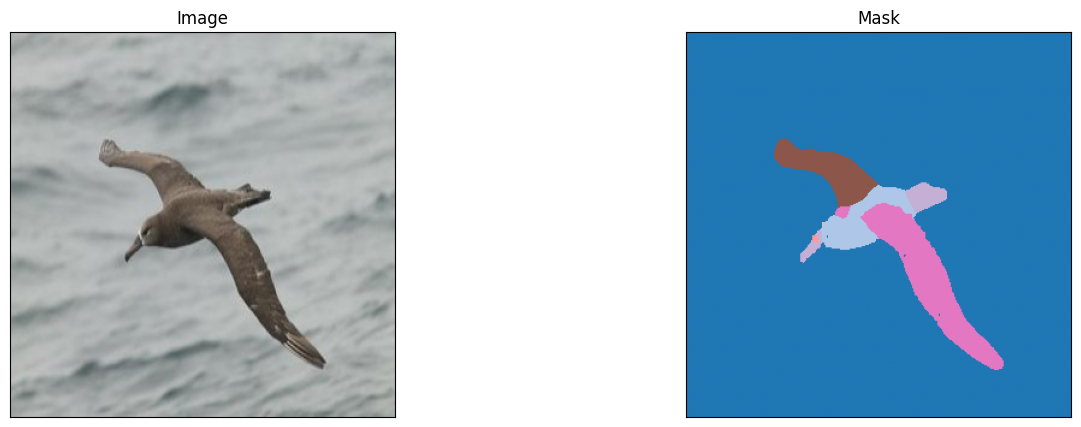

In [9]:
# Get a sample 
img, class_id = full_dataset[0]
# Predict mask and compute descriptors
mask = predict_mask(model=segmentation_model, image_tensor=img)
features = extract_all_features(img, mask)
# Print outputs
print(f'original image size: {img.size}','mask shape:', mask.shape, 'class_ids:', np.unique(mask))
print('feature length:', len(features))
print(features)
visualize(image=img, mask=mask)

original image size: <built-in method size of Tensor object at 0x7f05ee6d3e30> mask shape: (320, 320) class_ids: [ 0  1  2  4  5  6  7  9 11]
feature length: 2161
{'part1_area': np.float32(1739.0), 'part1_perimeter': np.float32(249.6579), 'part1_aspect_ratio': np.float32(2.9629946), 'part1_extent': np.float32(0.3600414), 'part1_solidity': np.float32(0.7627193), 'part1_eccentricity': np.float32(0.9413268), 'part1_orientation': np.float32(-0.87239325), 'part1_circularity': np.float32(0.35060558), 'part1_elongation': np.float32(0.6625036), 'part1_compactness': np.float32(2.852208), 'part1_sift_ds1': np.float32(17.67647), 'part1_sift_ds2': np.float32(19.735294), 'part1_sift_ds3': np.float32(17.205883), 'part1_sift_ds4': np.float32(21.147058), 'part1_sift_ds5': np.float32(18.117647), 'part1_sift_ds6': np.float32(11.176471), 'part1_sift_ds7': np.float32(19.294117), 'part1_sift_ds8': np.float32(10.529411), 'part1_sift_ds9': np.float32(51.82353), 'part1_sift_ds10': np.float32(26.264706), 'part

/tmp/ipykernel_499142/1869922507.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


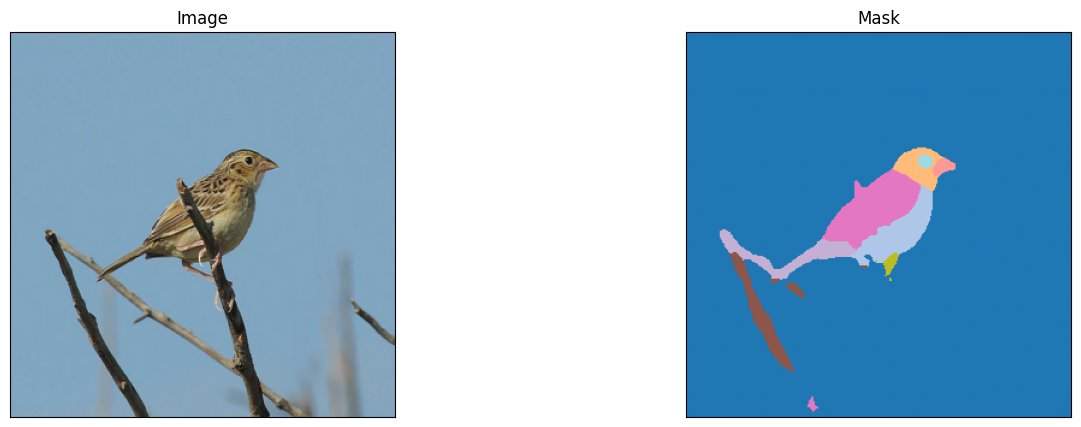

In [10]:
# Get a sample 
img, class_id = full_dataset[7077]
# Predict mask and compute descriptors
mask = predict_mask(model=segmentation_model, image_tensor=img)
features = extract_all_features(img, mask)
# Print outputs
print(f'original image size: {img.size}','mask shape:', mask.shape, 'class_ids:', np.unique(mask))
print('feature length:', len(features))
print(features)
visualize(image=img, mask=mask)

original image size: <built-in method size of Tensor object at 0x7f059c3c2390> mask shape: (320, 320) class_ids: [ 0  1  2  4  5  6  7 10 11]
feature length: 2161
{'part1_area': np.float32(3073.0), 'part1_perimeter': np.float32(232.99495), 'part1_aspect_ratio': np.float32(1.705263), 'part1_extent': np.float32(0.6488598), 'part1_solidity': np.float32(0.91431123), 'part1_eccentricity': np.float32(0.8100073), 'part1_orientation': np.float32(-0.56189835), 'part1_circularity': np.float32(0.7113436), 'part1_elongation': np.float32(0.41358018), 'part1_compactness': np.float32(1.4057904), 'part1_sift_ds1': np.float32(18.166666), 'part1_sift_ds2': np.float32(18.5), 'part1_sift_ds3': np.float32(27.833334), 'part1_sift_ds4': np.float32(16.5), 'part1_sift_ds5': np.float32(14.166667), 'part1_sift_ds6': np.float32(4.0), 'part1_sift_ds7': np.float32(15.166667), 'part1_sift_ds8': np.float32(24.666666), 'part1_sift_ds9': np.float32(73.0), 'part1_sift_ds10': np.float32(29.833334), 'part1_sift_ds11': np.

/tmp/ipykernel_499142/1869922507.py:58: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


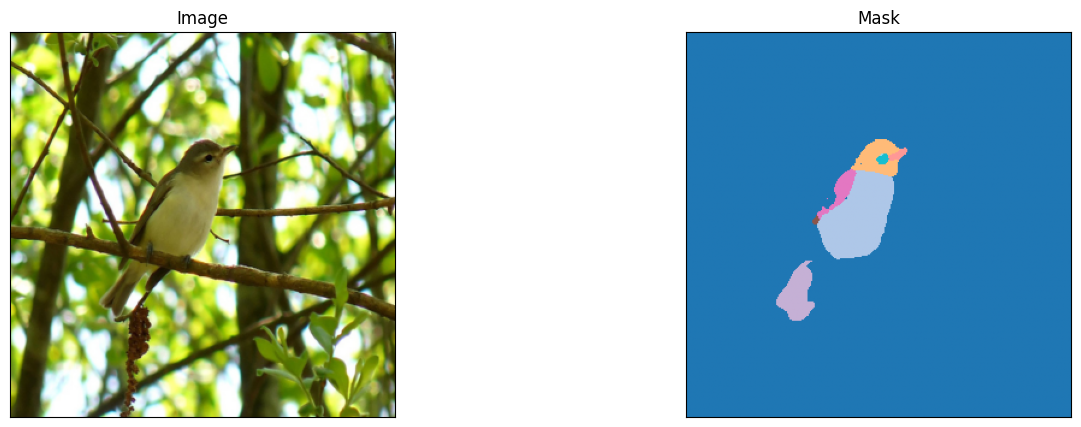

In [11]:
# Get a sample 
img, class_id = full_dataset[9077]
# Predict mask and compute descriptors
mask = predict_mask(model=segmentation_model, image_tensor=img)
features = extract_all_features(img, mask)
# Print outputs
print(f'original image size: {img.size}','mask shape:', mask.shape, 'class_ids:', np.unique(mask))
print('feature length:', len(features))
print(features)
visualize(image=img, mask=mask)

In [12]:
# --- Replace NaNs within each species group ---
def fill_by_class_mean(df, class_col="species"):
    df = df.replace(0, np.nan)
    df = df.dropna(axis=1, how='all')
    df_numeric = df.select_dtypes(include=[np.number])
    # Fill NaNs in numeric columns using the class-wise mean
    df[df_numeric.columns] = df.groupby(class_col)[df_numeric.columns].transform(
        lambda x: x.fillna(x.mean())
    )
    # Step 2: fill any remaining NaNs globally (for columns that were all NaN in a class)
    df[df_numeric.columns] = df[df_numeric.columns].fillna(df[df_numeric.columns].mean())
    return df

In [13]:
def extract_features_for_dataset(dataset, output_csv):
    records = []
    print(f"Extracting shape features for {len(dataset)} images...")

    # i = 0
    for idx, (img, class_id) in enumerate(tqdm(dataset)):
        mask = predict_mask(model=segmentation_model, image_tensor=img)
        features = extract_all_features(img, mask)
        img_path, _ = dataset.samples[idx]

        record = {"image": os.path.basename(img_path),
                  "class_id": class_id}
        record.update(features)
        records.append(record)

    df = pd.DataFrame(records)
    df.to_csv(output_csv, index=False)
    print(f"✅ Saved shape features to: {output_csv}")
    return df

In [14]:
os.makedirs(r"./shape_features_cub", exist_ok=True)

In [15]:
%%time
output_csv = r"./shape_features_cub/cub_shape_features.csv"
df = extract_features_for_dataset(full_dataset, output_csv)
df

Extracting shape features for 11788 images...


  6%|▋         | 748/11788 [21:29<4:42:07,  1.53s/it]/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:114: RuntimeWarning: invalid value encountered in scalar divide
  return (np.sum(np.abs(x)) / size) ** 2 / (np.sum(x ** 2) / size)
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/brisque/brisque.py:124: RuntimeWarning: invalid value encountered in divide
  return squares_sum / ((filtered_values.shape))
/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/pypiqe/piqe.py:142: RuntimeWarning: invalid value encountered in divide
  ipImage = np.round(255 * (ipImage / np.max(ipImage)))
100%|██████████| 11788/11788 [5:05:36<00:00,  1.56s/it] 


✅ Saved shape features to: ./shape_features_cub/cub_shape_features.csv
CPU times: user 12h 31min 27s, sys: 15min 46s, total: 12h 47min 13s
Wall time: 5h 6min 24s


,image,class_id,part1_area,part1_perimeter,part1_aspect_ratio,part1_extent,part1_solidity,part1_eccentricity,part1_orientation,part1_circularity,...,area_ratio_part9_to_part4,area_ratio_part9_to_part10,area_ratio_part10_to_part8,area_ratio_part10_to_part9,area_ratio_part3_to_part8,area_ratio_part8_to_part3,area_ratio_part10_to_part11,area_ratio_part11_to_part10,area_ratio_part3_to_part9,area_ratio_part9_to_part3
0,Black_Footed_Albatross_0001_796111.jpg,0,1733.0,2.802498e+02,2.451833,0.396205,0.636197,0.913045,-0.981756,2.772796e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Black_Footed_Albatross_0002_55.jpg,0,3173.0,3.209716e+02,1.939136,0.436571,0.685017,0.856773,-0.954378,3.870319e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Black_Footed_Albatross_0003_796136.jpg,0,1484.0,2.132670e+02,3.039578,0.607699,0.745729,0.944332,1.424403,4.100118e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Black_Footed_Albatross_0005_796090.jpg,0,3035.0,4.076762e+02,1.116284,0.438837,0.622692,0.444399,-0.610094,2.294763e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Black_Footed_Albatross_0006_796065.jpg,0,1874.0,2.030538e+02,2.810191,0.648892,0.876110,0.934544,-1.383102,5.711591e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11783,Common_Yellowthroat_0118_190805.jpg,199,3405.0,3.869899e+02,2.159456,0.415751,0.718809,0.886317,-0.405297,2.857115e-01,...,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11784,Common_Yellowthroat_0121_190597.jpg,199,3523.0,3.412203e+02,1.904097,0.553670,0.769382,0.850989,-0.319369,3.802355e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11785,Common_Yellowthroat_0122_190570.jpg,199,987.0,1.331604e+02,1.060823,0.559841,0.885996,0.333743,0.650913,6.994822e-01,...,0.867521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11786,Common_Yellowthroat_0125_190902.jpg,199,386.0,9.101219e+01,1.442437,0.493606,0.863535,0.720677,1.322599,5.855958e-01,...,0.958904,41.999992,1.25,0.02381,NaN,NaN,0.05814,17.199997,NaN,NaN
